# **nalara.academy**

## **Modul 3 - AI & Machine Learning**
### **Sesi 2: Menjinakkan Data Unstructured (EDA Citra & Ekstraksi Fitur)**

### **📌 Pengantar Sesi**
Di Sesi 1 kita melatih model dengan data Structured yang rapi. Sekarang kita hadapi tantangan
sebenarnya: **gambar**. ML Klasik (KNN, SVM, dsb) tidak bisa langsung "membaca" gambar mentah
seperti Deep Learning — ia butuh tabel angka. Tugas kita di sesi ini adalah menerjemahkan
gambar (Unstructured) menjadi tabel fitur (Structured) melalui proses **Feature Extraction**.

Sebelum sampai ke ekstraksi fitur, kita akan melakukan **EDA citra yang menyeluruh** —
memeriksa setiap potensi masalah pada dataset gambar, supaya kita paham betul kondisi data
sebelum diproses lebih jauh.

### **📦 Dataset: Healthy vs Diseased Leaf Image Dataset**

| Info | Detail |
|------|--------|
| 📌 Sumber | Kaggle |
| 👤 Author | amandam1 |
| 🔗 Link | https://www.kaggle.com/datasets/amandam1/healthy-vs-diseased-leaf-image-dataset |
| 🎯 Tugas | Klasifikasi daun **Sehat** vs **Sakit** |

In [1]:
# ============================================================
# SETUP KAGGLE API TOKEN
# Set KAGGLE_USERNAME & KAGGLE_KEY sebagai environment variable
# di terminal SEBELUM membuka notebook ini.
# ============================================================
import subprocess, os, zipfile

subprocess.run(["pip", "install", "kaggle", "--quiet"], check=True)

os.makedirs("dataset_daun", exist_ok=True)

print("⏳ Mengunduh dataset dari Kaggle...")
os.system("kaggle datasets download -d amandam1/healthy-vs-diseased-leaf-image-dataset -p dataset_daun --quiet")

zip_files = [f for f in os.listdir("dataset_daun") if f.endswith(".zip")]
if zip_files:
    zip_path = os.path.join("dataset_daun", zip_files[0])
    with zipfile.ZipFile(zip_path, "r") as z:
        z.extractall("dataset_daun")
    print("✅ Dataset berhasil diunduh & diekstrak ke folder 'dataset_daun/'")
else:
    print("❌ Gagal mengunduh. Pastikan KAGGLE_USERNAME & KAGGLE_KEY sudah di-set.")

⏳ Mengunduh dataset dari Kaggle...
✅ Dataset berhasil diunduh & diekstrak ke folder 'dataset_daun/'


In [2]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob
import hashlib
from collections import Counter
from PIL import Image

%matplotlib inline
sns.set_style("whitegrid")

print("✅ Semua library berhasil diimpor.")

✅ Semua library berhasil diimpor.


In [3]:
DATASET_PATH = "dataset_daun"

print("📁 STRUKTUR FOLDER DATASET")
print("=" * 50)
total_gambar = 0
for root, dirs, files in os.walk(DATASET_PATH):
    gambar = [f for f in files if f.lower().endswith((".jpg", ".jpeg", ".png"))]
    if not gambar:
        continue
    level  = root.replace(DATASET_PATH, "").count(os.sep)
    indent = "    " * level + "├── "
    nama   = os.path.basename(root)
    print(f"{indent}{nama}/  ->  {len(gambar)} gambar")
    total_gambar += len(gambar)
print("=" * 50)
print(f"📊 Total gambar keseluruhan : {total_gambar}")

📁 STRUKTUR FOLDER DATASET
            ├── diseased/  ->  254 gambar
            ├── healthy/  ->  179 gambar
            ├── diseased/  ->  232 gambar
            ├── healthy/  ->  220 gambar
            ├── diseased/  ->  120 gambar
            ├── healthy/  ->  103 gambar
            ├── diseased/  ->  142 gambar
            ├── healthy/  ->  277 gambar
            ├── diseased/  ->  345 gambar
            ├── healthy/  ->  279 gambar
            ├── diseased/  ->  124 gambar
            ├── healthy/  ->  133 gambar
            ├── diseased/  ->  77 gambar
            ├── healthy/  ->  159 gambar
            ├── diseased/  ->  265 gambar
            ├── healthy/  ->  170 gambar
            ├── diseased/  ->  272 gambar
            ├── healthy/  ->  287 gambar
            ├── diseased/  ->  276 gambar
            ├── healthy/  ->  322 gambar
📊 Total gambar keseluruhan : 4236


In [4]:
# Kumpulkan seluruh path gambar beserta label kelasnya (dari nama folder induk)
semua_path  = []
semua_label = []

for ekstensi in ["*.jpg", "*.jpeg", "*.JPG", "*.png"]:
    for path in glob.glob(os.path.join(DATASET_PATH, "**", ekstensi), recursive=True):
        semua_path.append(path)
        semua_label.append(os.path.basename(os.path.dirname(path)))

df_path = pd.DataFrame({"path": semua_path, "label": semua_label})
print(f"✅ Total {len(df_path)} gambar berhasil diindeks.")
df_path.head()

✅ Total 8472 gambar berhasil diindeks.


,path,label
0,dataset_daun\A Database of Leaf Images\Alstoni...,diseased
1,dataset_daun\A Database of Leaf Images\Alstoni...,diseased
2,dataset_daun\A Database of Leaf Images\Alstoni...,diseased
3,dataset_daun\A Database of Leaf Images\Alstoni...,diseased
4,dataset_daun\A Database of Leaf Images\Alstoni...,diseased


## **🔬 EDA Citra Menyeluruh**

Berikut kita periksa satu per satu seluruh kategori potensi masalah pada dataset citra:
distribusi data & label, pencahayaan & warna, kualitas & artefak digital, hingga geometri &
lingkungan objek.

### **1️⃣ Karakteristik Distribusi Data & Label**

#### **1.1 Class Imbalance**

C:\Users\Asus\AppData\Local\Temp\ipykernel_12924\3806687775.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=distribusi_kelas.index, y=distribusi_kelas.values, palette="viridis")


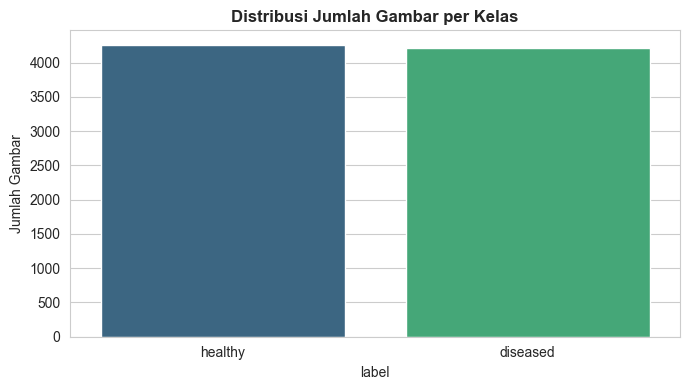

label
healthy     4258
diseased    4214
Name: count, dtype: int64

📐 Rasio ketimpangan kelas: 1.01x
✅ Distribusi kelas relatif seimbang.


In [5]:
distribusi_kelas = df_path["label"].value_counts()

plt.figure(figsize=(7, 4))
sns.barplot(x=distribusi_kelas.index, y=distribusi_kelas.values, palette="viridis")
plt.title("Distribusi Jumlah Gambar per Kelas", fontsize=12, fontweight="bold")
plt.ylabel("Jumlah Gambar")
plt.tight_layout()
plt.show()

print(distribusi_kelas)
rasio = distribusi_kelas.max() / distribusi_kelas.min()
print(f"\n📐 Rasio ketimpangan kelas: {rasio:.2f}x")
if rasio > 2:
    print("⚠️  Class imbalance signifikan -- pertimbangkan stratified split / class_weight saat training.")
else:
    print("✅ Distribusi kelas relatif seimbang.")

#### **1.2 Variasi Ukuran & Aspect Ratio**

In [6]:
# Ambil sampel agar proses pengecekan tidak terlalu lama jika dataset besar
SAMPLE_SIZE = min(300, len(df_path))
df_sampel = df_path.sample(SAMPLE_SIZE, random_state=42).reset_index(drop=True)

dimensi_list = []
for path in df_sampel["path"]:
    img = cv2.imread(path)
    if img is not None:
        h, w = img.shape[:2]
        dimensi_list.append({"path": path, "width": w, "height": h, "aspect_ratio": round(w / h, 2)})

df_dimensi = pd.DataFrame(dimensi_list)

print(f"📐 Variasi ukuran gambar dari {len(df_dimensi)} sampel:")
print(df_dimensi[["width", "height", "aspect_ratio"]].describe())

📐 Variasi ukuran gambar dari 300 sampel:
        width  height  aspect_ratio
count   300.0   300.0         300.0
mean   6000.0  4000.0           1.5
std       0.0     0.0           0.0
min    6000.0  4000.0           1.5
25%    6000.0  4000.0           1.5
50%    6000.0  4000.0           1.5
75%    6000.0  4000.0           1.5
max    6000.0  4000.0           1.5


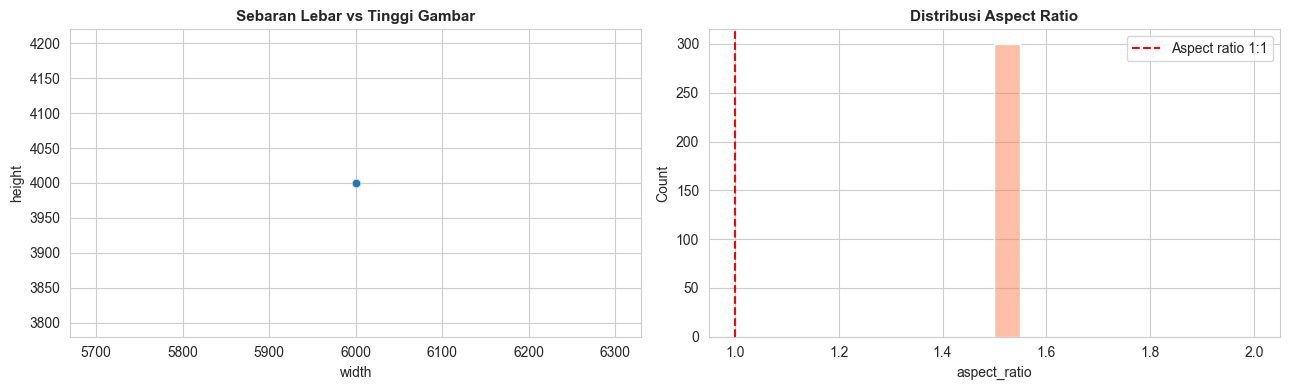


💡 Ditemukan 1 kombinasi ukuran berbeda dari 300 sampel.
   Karena ukuran bervariasi, semua gambar WAJIB di-resize ke ukuran seragam
   sebelum diproses lebih lanjut (misal 224x224 px untuk model standar).


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.scatterplot(data=df_dimensi, x="width", y="height", ax=axes[0], alpha=0.5)
axes[0].set_title("Sebaran Lebar vs Tinggi Gambar", fontsize=11, fontweight="bold")

sns.histplot(df_dimensi["aspect_ratio"], bins=20, kde=True, ax=axes[1], color="coral")
axes[1].axvline(1.0, color="red", linestyle="--", label="Aspect ratio 1:1")
axes[1].set_title("Distribusi Aspect Ratio", fontsize=11, fontweight="bold")
axes[1].legend()

plt.tight_layout()
plt.show()

ukuran_unik = df_dimensi[["width", "height"]].drop_duplicates().shape[0]
print(f"\n💡 Ditemukan {ukuran_unik} kombinasi ukuran berbeda dari {len(df_dimensi)} sampel.")
print("   Karena ukuran bervariasi, semua gambar WAJIB di-resize ke ukuran seragam")
print("   sebelum diproses lebih lanjut (misal 224x224 px untuk model standar).")

#### **1.3 Duplikasi Data**

In [8]:
def hitung_hash_gambar(path):
    """Menghasilkan hash MD5 dari isi file gambar untuk mendeteksi duplikat persis."""
    try:
        with open(path, "rb") as f:
            return hashlib.md5(f.read()).hexdigest()
    except Exception:
        return None

print("⏳ Menghitung hash untuk deteksi duplikat (pada sampel)...")
df_sampel["hash"] = df_sampel["path"].apply(hitung_hash_gambar)

jumlah_duplikat = df_sampel["hash"].duplicated().sum()
print(f"🔁 Jumlah gambar duplikat persis (exact duplicate) pada sampel: {jumlah_duplikat}")

if jumlah_duplikat > 0:
    print("⚠️  Ditemukan duplikasi -- berisiko membuat evaluasi model menjadi bias")
    print("   (gambar yang sama bisa muncul di data train DAN test sekaligus).")
else:
    print("✅ Tidak ditemukan duplikasi persis pada sampel yang diperiksa.")

print("\n💡 Catatan: ini baru deteksi duplikat PERSIS (hash sama persis).")
print("   Untuk deteksi gambar 'sangat mirip' (near-duplicate) dibutuhkan teknik")
print("   tambahan seperti perceptual hashing (phash) atau image embedding similarity.")

⏳ Menghitung hash untuk deteksi duplikat (pada sampel)...
🔁 Jumlah gambar duplikat persis (exact duplicate) pada sampel: 3
⚠️  Ditemukan duplikasi -- berisiko membuat evaluasi model menjadi bias
   (gambar yang sama bisa muncul di data train DAN test sekaligus).

💡 Catatan: ini baru deteksi duplikat PERSIS (hash sama persis).
   Untuk deteksi gambar 'sangat mirip' (near-duplicate) dibutuhkan teknik
   tambahan seperti perceptual hashing (phash) atau image embedding similarity.


#### **1.4 Mislabeled Data (Pengecekan Visual)**

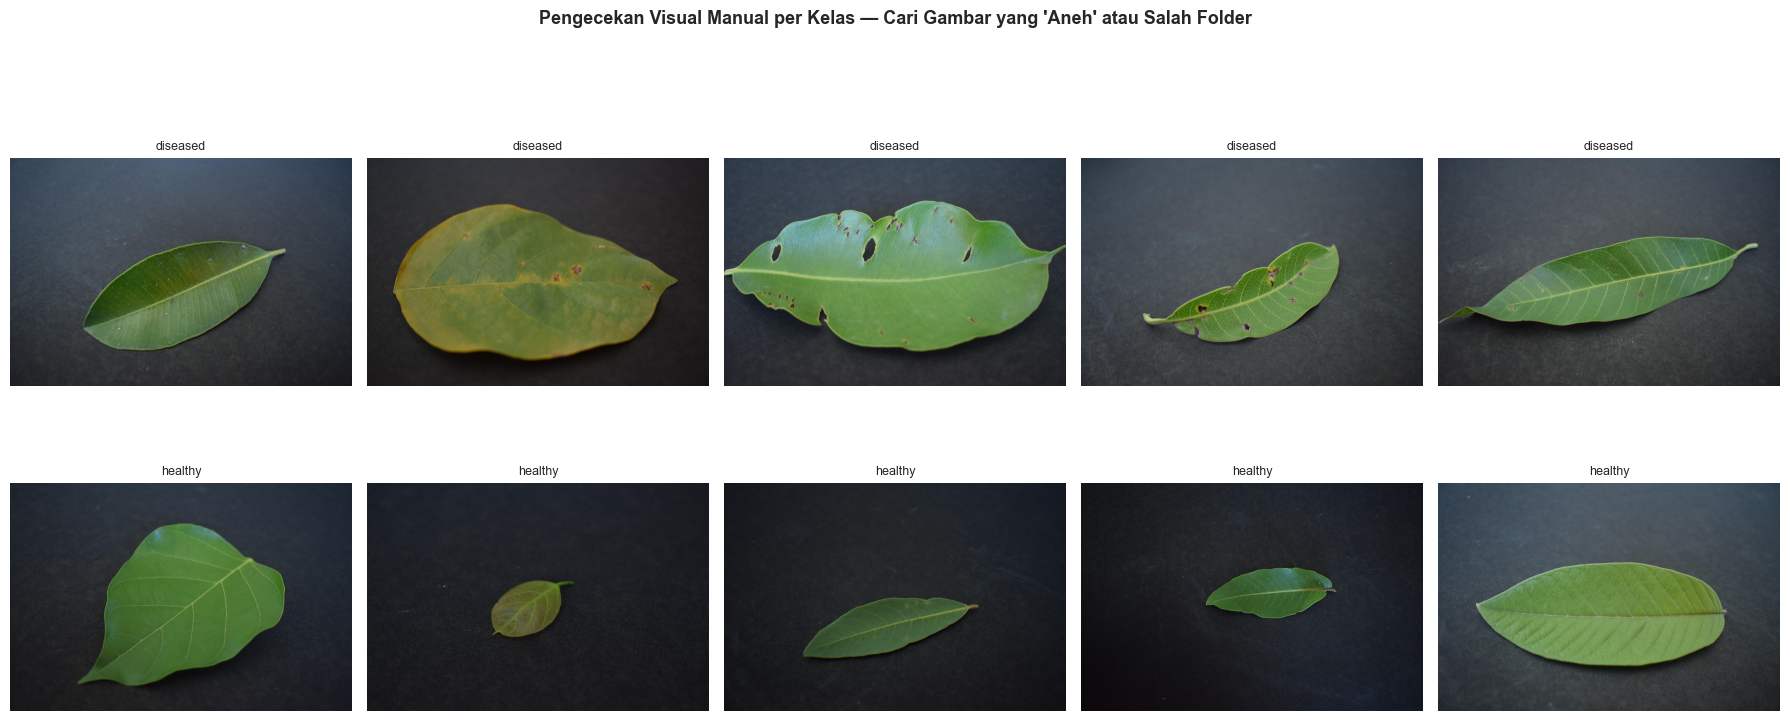

💡 Periksa secara manual: apakah ada gambar yang jelas-jelas tidak sesuai labelnya?
   (misal foto bukan daun, atau daun sehat masuk folder sakit, dsb)


In [9]:
# Mislabeled data sulit dideteksi otomatis tanpa model -- cara paling praktis di tahap EDA
# adalah menampilkan sampel acak dari tiap kelas untuk diperiksa secara visual oleh manusia.
kelas_unik = df_path["label"].unique()

fig, axes = plt.subplots(len(kelas_unik), 5, figsize=(18, 4 * len(kelas_unik)))

for i, kelas in enumerate(kelas_unik):
    sampel_kelas = df_path[df_path["label"] == kelas].sample(min(5, len(df_path[df_path["label"] == kelas])), random_state=1)
    for j, path in enumerate(sampel_kelas["path"]):
        img = cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2RGB)
        ax = axes[i, j] if len(kelas_unik) > 1 else axes[j]
        ax.imshow(img)
        ax.set_title(kelas, fontsize=9)
        ax.axis("off")

plt.suptitle("Pengecekan Visual Manual per Kelas — Cari Gambar yang 'Aneh' atau Salah Folder",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

print("💡 Periksa secara manual: apakah ada gambar yang jelas-jelas tidak sesuai labelnya?")
print("   (misal foto bukan daun, atau daun sehat masuk folder sakit, dsb)")

### **2️⃣ Karakteristik Pencahayaan & Warna**

#### **2.1 Overexposure & Underexposure (via Histogram Kecerahan)**

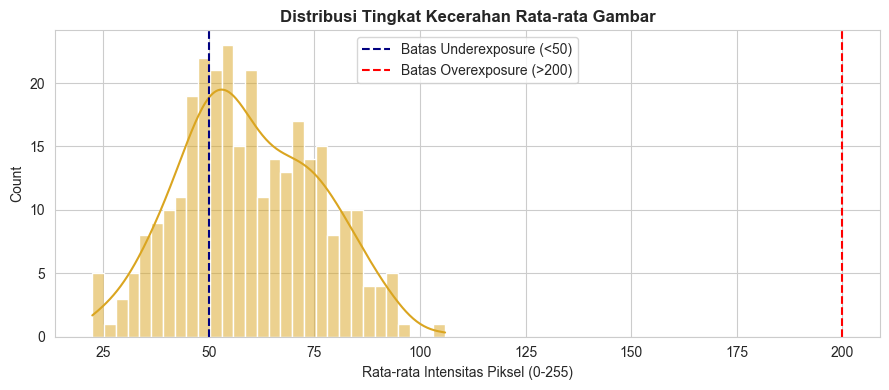

🌑 Gambar berpotensi underexposure (terlalu gelap) : 90 dari 300
☀️  Gambar berpotensi overexposure (terlalu terang) : 0 dari 300


In [10]:
def hitung_brightness(path):
    img = cv2.imread(path)
    if img is None:
        return None
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    return np.mean(gray)

df_sampel["brightness"] = df_sampel["path"].apply(hitung_brightness)

plt.figure(figsize=(9, 4))
sns.histplot(df_sampel["brightness"].dropna(), bins=30, kde=True, color="goldenrod")
plt.axvline(50, color="navy", linestyle="--", label="Batas Underexposure (<50)")
plt.axvline(200, color="red", linestyle="--", label="Batas Overexposure (>200)")
plt.title("Distribusi Tingkat Kecerahan Rata-rata Gambar", fontsize=12, fontweight="bold")
plt.xlabel("Rata-rata Intensitas Piksel (0-255)")
plt.legend()
plt.tight_layout()
plt.show()

gelap  = (df_sampel["brightness"] < 50).sum()
terang = (df_sampel["brightness"] > 200).sum()
print(f"🌑 Gambar berpotensi underexposure (terlalu gelap) : {gelap} dari {len(df_sampel)}")
print(f"☀️  Gambar berpotensi overexposure (terlalu terang) : {terang} dari {len(df_sampel)}")

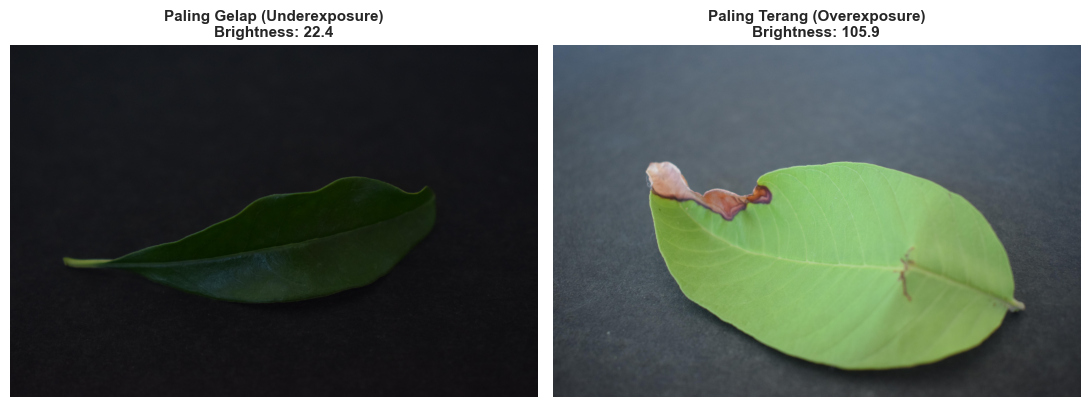

In [11]:
# Tampilkan contoh gambar paling gelap & paling terang dari sampel
df_terurut = df_sampel.dropna(subset=["brightness"]).sort_values("brightness")
paling_gelap  = df_terurut.iloc[0]
paling_terang = df_terurut.iloc[-1]

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
for ax, baris, judul in zip(axes, [paling_gelap, paling_terang], ["Paling Gelap (Underexposure)", "Paling Terang (Overexposure)"]):
    img = cv2.cvtColor(cv2.imread(baris["path"]), cv2.COLOR_BGR2RGB)
    ax.imshow(img)
    ax.set_title(f"{judul}\nBrightness: {baris['brightness']:.1f}", fontsize=11, fontweight="bold")
    ax.axis("off")
plt.tight_layout()
plt.show()

#### **2.2 Kontras Rendah (Low Contrast)**

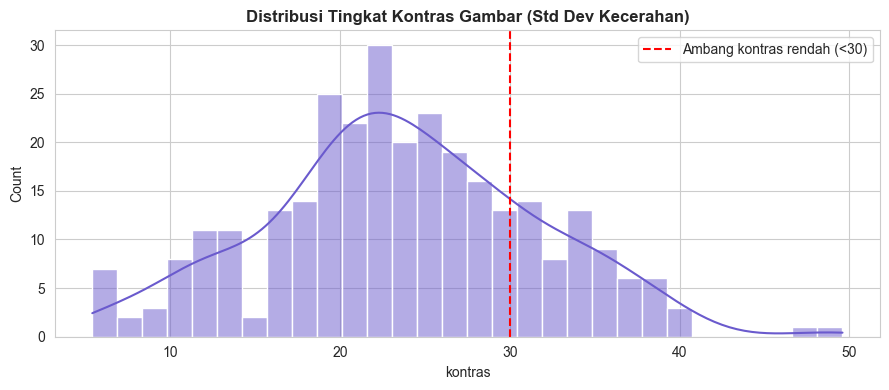

⚠️  Gambar dengan kontras rendah (<30): 238 dari 300
💡 Kontras rendah membuat batas objek (daun) dan latar belakang sulit dibedakan,
   yang nantinya bisa mengaburkan fitur warna/bentuk saat ekstraksi fitur.


In [12]:
def hitung_kontras(path):
    img = cv2.imread(path)
    if img is None:
        return None
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    return np.std(gray)  # standar deviasi = ukuran sebaran/kontras kecerahan

df_sampel["kontras"] = df_sampel["path"].apply(hitung_kontras)

plt.figure(figsize=(9, 4))
sns.histplot(df_sampel["kontras"].dropna(), bins=30, kde=True, color="slateblue")
plt.axvline(30, color="red", linestyle="--", label="Ambang kontras rendah (<30)")
plt.title("Distribusi Tingkat Kontras Gambar (Std Dev Kecerahan)", fontsize=12, fontweight="bold")
plt.legend()
plt.tight_layout()
plt.show()

kontras_rendah = (df_sampel["kontras"] < 30).sum()
print(f"⚠️  Gambar dengan kontras rendah (<30): {kontras_rendah} dari {len(df_sampel)}")
print("💡 Kontras rendah membuat batas objek (daun) dan latar belakang sulit dibedakan,")
print("   yang nantinya bisa mengaburkan fitur warna/bentuk saat ekstraksi fitur.")

#### **2.3 Ketidakseimbangan Warna (Color Cast)**

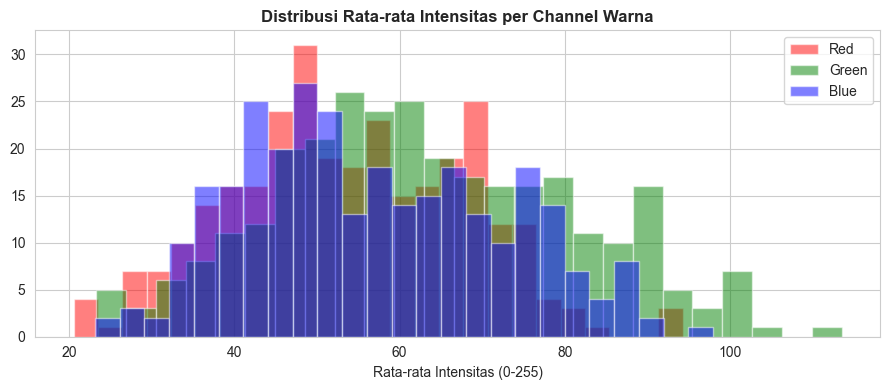

💡 Jika satu channel warna secara konsisten jauh lebih tinggi/rendah dari yang lain
   di seluruh dataset, ini menandakan adanya 'Color Cast' (dominasi warna akibat
   sumber cahaya tertentu) yang bisa memengaruhi fitur histogram warna nantinya.


In [13]:
def hitung_rata_channel(path):
    img = cv2.imread(path)
    if img is None:
        return None, None, None
    b, g, r = cv2.split(img)
    return np.mean(b), np.mean(g), np.mean(r)

hasil_channel = df_sampel["path"].apply(hitung_rata_channel)
df_sampel["mean_b"] = hasil_channel.apply(lambda x: x[0])
df_sampel["mean_g"] = hasil_channel.apply(lambda x: x[1])
df_sampel["mean_r"] = hasil_channel.apply(lambda x: x[2])

plt.figure(figsize=(9, 4))
plt.hist(df_sampel["mean_r"].dropna(), bins=25, alpha=0.5, label="Red",   color="red")
plt.hist(df_sampel["mean_g"].dropna(), bins=25, alpha=0.5, label="Green", color="green")
plt.hist(df_sampel["mean_b"].dropna(), bins=25, alpha=0.5, label="Blue",  color="blue")
plt.title("Distribusi Rata-rata Intensitas per Channel Warna", fontsize=12, fontweight="bold")
plt.xlabel("Rata-rata Intensitas (0-255)")
plt.legend()
plt.tight_layout()
plt.show()

print("💡 Jika satu channel warna secara konsisten jauh lebih tinggi/rendah dari yang lain")
print("   di seluruh dataset, ini menandakan adanya 'Color Cast' (dominasi warna akibat")
print("   sumber cahaya tertentu) yang bisa memengaruhi fitur histogram warna nantinya.")

#### **2.4 & 2.5 Gradien Cahaya Tidak Merata & Refleksi/Glare**

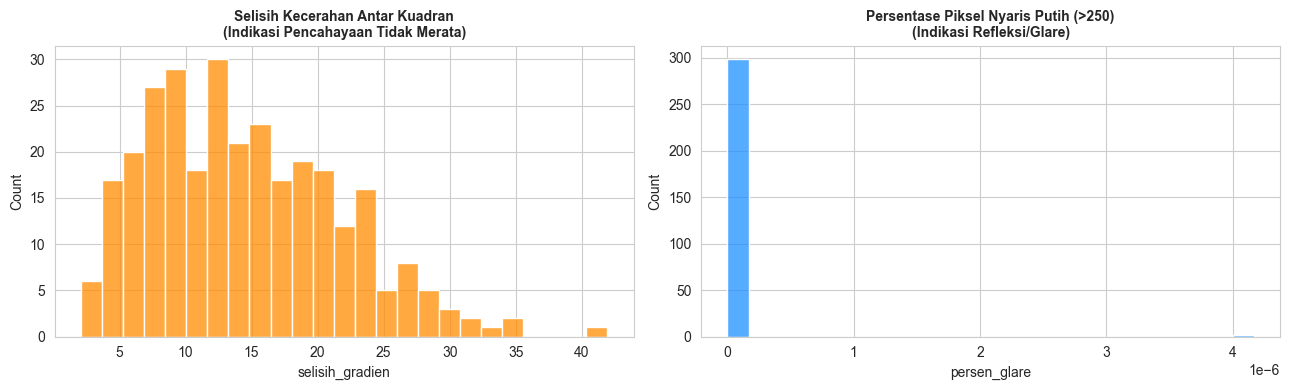

⚠️  Gambar dengan pencahayaan tidak merata (selisih kuadran >50) : 0
⚠️  Gambar dengan indikasi glare/refleksi (>5% piksel nyaris putih) : 0


In [14]:
def cek_gradien_dan_glare(path):
    """
    Membagi gambar jadi 4 kuadran, bandingkan rata-rata kecerahannya untuk mendeteksi
    pencahayaan tidak merata. Glare/refleksi dideteksi dari persentase piksel yang
    nyaris putih sempurna (>250).
    """
    img = cv2.imread(path)
    if img is None:
        return None
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    h, w = gray.shape

    kuadran = [
        gray[0:h//2, 0:w//2], gray[0:h//2, w//2:w],
        gray[h//2:h, 0:w//2], gray[h//2:h, w//2:w]
    ]
    rata_kuadran = [np.mean(k) for k in kuadran]
    selisih_gradien = max(rata_kuadran) - min(rata_kuadran)

    persen_glare = np.mean(gray > 250) * 100

    return selisih_gradien, persen_glare

hasil_gradien = df_sampel["path"].apply(cek_gradien_dan_glare)
df_sampel["selisih_gradien"] = hasil_gradien.apply(lambda x: x[0] if x else None)
df_sampel["persen_glare"]    = hasil_gradien.apply(lambda x: x[1] if x else None)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(df_sampel["selisih_gradien"].dropna(), bins=25, ax=axes[0], color="darkorange")
axes[0].set_title("Selisih Kecerahan Antar Kuadran\n(Indikasi Pencahayaan Tidak Merata)", fontsize=10, fontweight="bold")

sns.histplot(df_sampel["persen_glare"].dropna(), bins=25, ax=axes[1], color="dodgerblue")
axes[1].set_title("Persentase Piksel Nyaris Putih (>250)\n(Indikasi Refleksi/Glare)", fontsize=10, fontweight="bold")

plt.tight_layout()
plt.show()

gradien_tinggi = (df_sampel["selisih_gradien"] > 50).sum()
glare_tinggi   = (df_sampel["persen_glare"] > 5).sum()
print(f"⚠️  Gambar dengan pencahayaan tidak merata (selisih kuadran >50) : {gradien_tinggi}")
print(f"⚠️  Gambar dengan indikasi glare/refleksi (>5% piksel nyaris putih) : {glare_tinggi}")

### **3️⃣ Kualitas Citra & Artefak Digital**

#### **3.1 Sensor Noise**

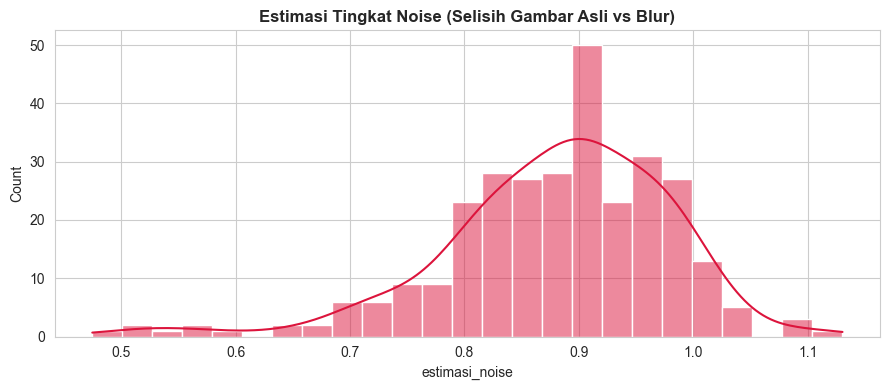

💡 Semakin tinggi nilai estimasi noise, semakin banyak detail bintik-bintik kecil
   yang kemungkinan adalah noise sensor, bukan tepi/detail objek asli.


In [15]:
def estimasi_noise(path):
    """
    Estimasi noise dengan membandingkan gambar asli dan versi yang sudah di-blur.
    Selisih besar -> banyak detail tinggi-frekuensi yang bisa jadi adalah noise.
    """
    img = cv2.imread(path)
    if img is None:
        return None
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(gray, (5, 5), 0)
    selisih = cv2.absdiff(gray, blur)
    return np.mean(selisih)

df_sampel["estimasi_noise"] = df_sampel["path"].apply(estimasi_noise)

plt.figure(figsize=(9, 4))
sns.histplot(df_sampel["estimasi_noise"].dropna(), bins=25, kde=True, color="crimson")
plt.title("Estimasi Tingkat Noise (Selisih Gambar Asli vs Blur)", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

print("💡 Semakin tinggi nilai estimasi noise, semakin banyak detail bintik-bintik kecil")
print("   yang kemungkinan adalah noise sensor, bukan tepi/detail objek asli.")

#### **3.2 Blur & Motion Artifacts**

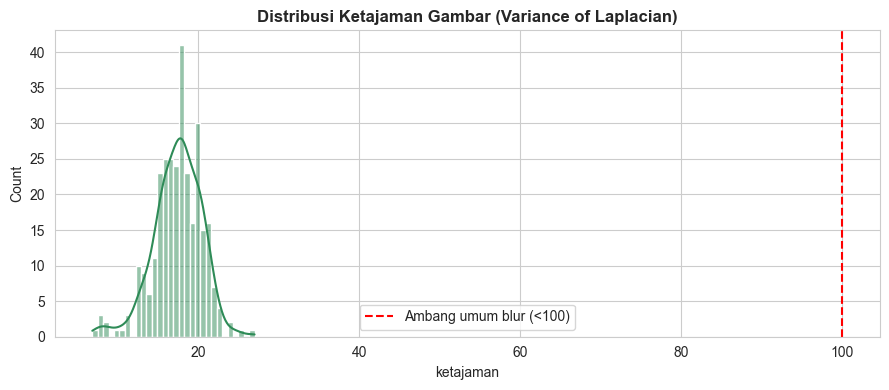

🌫️  Gambar yang berpotensi blur (skor ketajaman <100): 300 dari 300


In [16]:
def hitung_ketajaman(path):
    """
    Variance of Laplacian -- metrik standar untuk mengukur ketajaman gambar.
    Nilai rendah = gambar blur, nilai tinggi = gambar tajam.
    """
    img = cv2.imread(path)
    if img is None:
        return None
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    return cv2.Laplacian(gray, cv2.CV_64F).var()

df_sampel["ketajaman"] = df_sampel["path"].apply(hitung_ketajaman)

plt.figure(figsize=(9, 4))
sns.histplot(df_sampel["ketajaman"].dropna(), bins=30, kde=True, color="seagreen")
plt.axvline(100, color="red", linestyle="--", label="Ambang umum blur (<100)")
plt.title("Distribusi Ketajaman Gambar (Variance of Laplacian)", fontsize=12, fontweight="bold")
plt.legend()
plt.tight_layout()
plt.show()

gambar_blur = (df_sampel["ketajaman"] < 100).sum()
print(f"🌫️  Gambar yang berpotensi blur (skor ketajaman <100): {gambar_blur} dari {len(df_sampel)}")

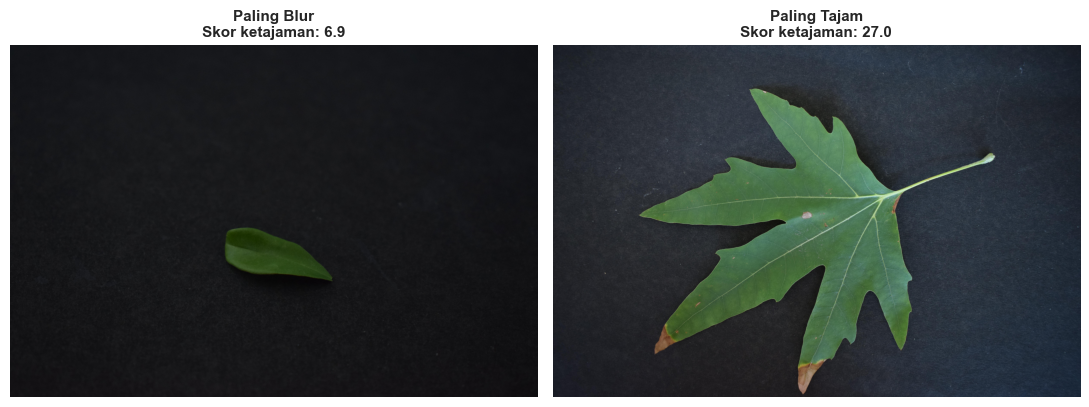

In [17]:
# Tampilkan contoh gambar paling blur dan paling tajam
df_ketajaman_sorted = df_sampel.dropna(subset=["ketajaman"]).sort_values("ketajaman")
paling_blur  = df_ketajaman_sorted.iloc[0]
paling_tajam = df_ketajaman_sorted.iloc[-1]

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
for ax, baris, judul in zip(axes, [paling_blur, paling_tajam], ["Paling Blur", "Paling Tajam"]):
    img = cv2.cvtColor(cv2.imread(baris["path"]), cv2.COLOR_BGR2RGB)
    ax.imshow(img)
    ax.set_title(f"{judul}\nSkor ketajaman: {baris['ketajaman']:.1f}", fontsize=11, fontweight="bold")
    ax.axis("off")
plt.tight_layout()
plt.show()

#### **3.3 Kompresi Artefak (JPEG Artifacts)**

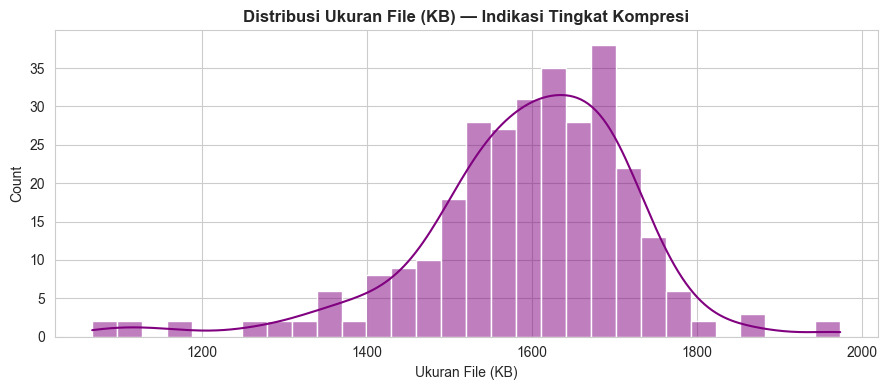

📋 Format file yang ditemukan:
format_file
JPEG    300
Name: count, dtype: int64

💡 File berukuran sangat kecil relatif terhadap resolusinya mengindikasikan
   kompresi JPEG agresif, yang berpotensi menimbulkan artefak kotak-kotak (blocking).


In [18]:
def cek_kualitas_jpeg(path):
    """Mengecek metadata kualitas kompresi JPEG menggunakan PIL (jika tersedia)."""
    try:
        img = Image.open(path)
        return img.format, os.path.getsize(path) / 1024  # ukuran dalam KB
    except Exception:
        return None, None

df_sampel[["format_file", "ukuran_kb"]] = df_sampel["path"].apply(
    lambda p: pd.Series(cek_kualitas_jpeg(p))
)

plt.figure(figsize=(9, 4))
sns.histplot(df_sampel["ukuran_kb"].dropna(), bins=30, kde=True, color="purple")
plt.title("Distribusi Ukuran File (KB) — Indikasi Tingkat Kompresi", fontsize=12, fontweight="bold")
plt.xlabel("Ukuran File (KB)")
plt.tight_layout()
plt.show()

print("📋 Format file yang ditemukan:")
print(df_sampel["format_file"].value_counts())
print()
print("💡 File berukuran sangat kecil relatif terhadap resolusinya mengindikasikan")
print("   kompresi JPEG agresif, yang berpotensi menimbulkan artefak kotak-kotak (blocking).")

#### **3.4 Corrupted Files**

In [19]:
def cek_file_rusak(path):
    """Coba buka file dengan PIL.verify() -- jika gagal, file dianggap rusak/corrupt."""
    try:
        img = Image.open(path)
        img.verify()
        return True
    except Exception:
        return False

print("⏳ Memeriksa seluruh file untuk file yang corrupt/rusak...")
df_path["file_valid"] = df_path["path"].apply(cek_file_rusak)

jumlah_rusak = (~df_path["file_valid"]).sum()
print(f"\n🩹 Total file corrupt/rusak ditemukan: {jumlah_rusak} dari {len(df_path)}")

if jumlah_rusak > 0:
    print("\n⚠️  Daftar file rusak (akan dikeluarkan dari proses berikutnya):")
    print(df_path[~df_path["file_valid"]]["path"].tolist()[:10])
    df_path = df_path[df_path["file_valid"]].reset_index(drop=True)
    print(f"\n✅ Dataset bersih sekarang berisi {len(df_path)} gambar valid.")
else:
    print("✅ Tidak ditemukan file corrupt -- seluruh gambar berhasil dibaca dengan baik.")

⏳ Memeriksa seluruh file untuk file yang corrupt/rusak...

🩹 Total file corrupt/rusak ditemukan: 0 dari 8472
✅ Tidak ditemukan file corrupt -- seluruh gambar berhasil dibaca dengan baik.


### **4️⃣ Karakteristik Geometri & Lingkungan Objek**

Empat karakteristik berikut — **Variasi Sudut Pandang**, **Oklusi**, **Skala Objek**, dan
**Latar Belakang Rumit** — sulit diukur dengan satu angka statistik sederhana seperti
kategori sebelumnya. Cara paling efektif di tahap EDA adalah **pengecekan visual** terhadap
sampel acak dari dataset, sambil mencatat polanya secara kualitatif.

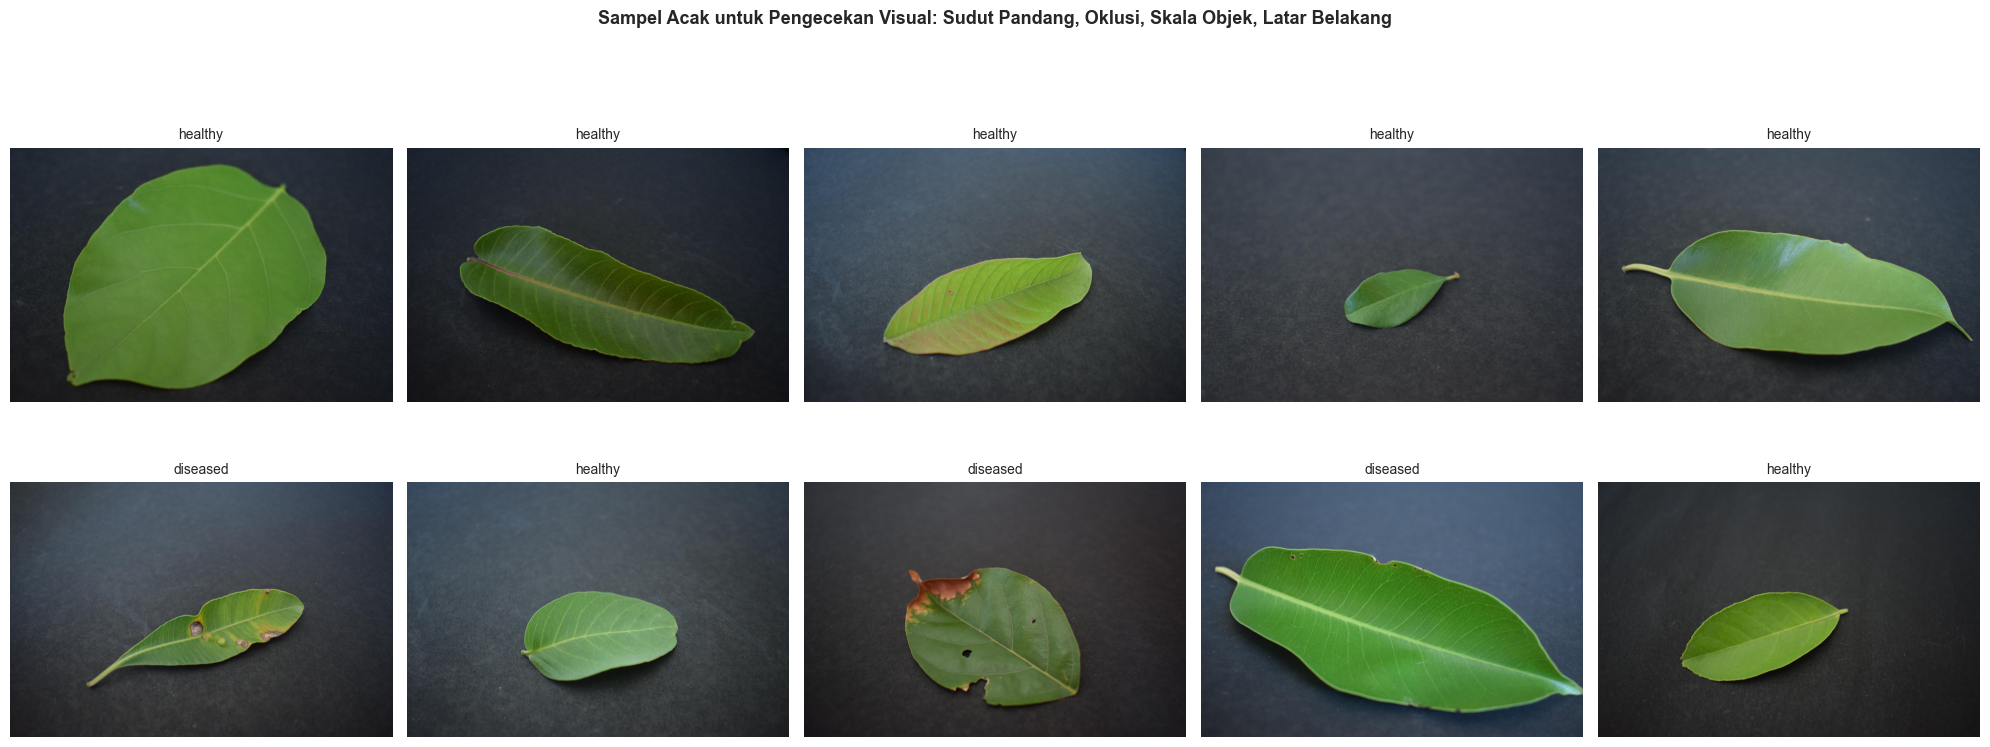

📝 Checklist pengecekan visual manual:
   [ ] Apakah objek daun difoto dari sudut pandang yang bervariasi (atas/samping/miring)?
   [ ] Apakah ada objek lain yang menutupi sebagian daun (oklusi)?
   [ ] Apakah ukuran daun dalam frame bervariasi (close-up vs jarak jauh)?
   [ ] Apakah latar belakang bersih (polos) atau rumit (banyak daun/tanah/tangan lain)?


In [20]:
sampel_geometri = df_path.sample(min(10, len(df_path)), random_state=7)

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for ax, (_, baris) in zip(axes, sampel_geometri.iterrows()):
    img = cv2.cvtColor(cv2.imread(baris["path"]), cv2.COLOR_BGR2RGB)
    ax.imshow(img)
    ax.set_title(baris["label"], fontsize=10)
    ax.axis("off")

plt.suptitle("Sampel Acak untuk Pengecekan Visual: Sudut Pandang, Oklusi, Skala Objek, Latar Belakang",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

print("📝 Checklist pengecekan visual manual:")
print("   [ ] Apakah objek daun difoto dari sudut pandang yang bervariasi (atas/samping/miring)?")
print("   [ ] Apakah ada objek lain yang menutupi sebagian daun (oklusi)?")
print("   [ ] Apakah ukuran daun dalam frame bervariasi (close-up vs jarak jauh)?")
print("   [ ] Apakah latar belakang bersih (polos) atau rumit (banyak daun/tanah/tangan lain)?")

## **🧮 5. Feature Extraction — Mengubah Gambar Menjadi Tabel Angka**

Setelah memahami kondisi data secara menyeluruh, sekarang kita "memeras esensi" tiap gambar
menjadi angka. Kita gunakan **Histogram Warna** sebagai fitur utama: representasi sederhana
namun cukup informatif untuk membedakan daun sehat (umumnya hijau merata) vs daun sakit
(biasanya ada bercak coklat/kuning).

In [21]:
def ekstrak_histogram_warna(path, bins=8):
    """
    Mengekstrak histogram warna dari 3 channel (B, G, R), masing-masing dibagi
    menjadi sejumlah 'bins' rentang intensitas. Hasil akhirnya digabung jadi satu
    vektor fitur datar (flatten).
    """
    img = cv2.imread(path)
    if img is None:
        return None

    # Resize dulu agar seluruh gambar memiliki bobot piksel yang setara
    img = cv2.resize(img, (128, 128))

    fitur = []
    for channel_idx in range(3):  # B, G, R
        hist = cv2.calcHist([img], [channel_idx], None, [bins], [0, 256])
        hist = cv2.normalize(hist, hist).flatten()
        fitur.extend(hist)

    return fitur

# Uji coba pada satu gambar
contoh_path = df_path.iloc[0]["path"]
contoh_fitur = ekstrak_histogram_warna(contoh_path)
print(f"✅ Berhasil mengekstrak {len(contoh_fitur)} fitur dari satu gambar.")
print(f"   (3 channel warna x 8 bins = 24 fitur)")

✅ Berhasil mengekstrak 24 fitur dari satu gambar.
   (3 channel warna x 8 bins = 24 fitur)


In [22]:
print("⏳ Mengekstrak histogram warna dari seluruh dataset...")
print("   (proses ini mungkin memakan waktu beberapa menit tergantung jumlah gambar)")

daftar_fitur = []
daftar_label = []
daftar_path_gagal = []

for idx, baris in df_path.iterrows():
    fitur = ekstrak_histogram_warna(baris["path"])
    if fitur is not None:
        daftar_fitur.append(fitur)
        daftar_label.append(baris["label"])
    else:
        daftar_path_gagal.append(baris["path"])

print(f"\n✅ Ekstraksi selesai: {len(daftar_fitur)} gambar berhasil diproses.")
if daftar_path_gagal:
    print(f"⚠️  {len(daftar_path_gagal)} gambar gagal diproses dan dilewati.")

⏳ Mengekstrak histogram warna dari seluruh dataset...
   (proses ini mungkin memakan waktu beberapa menit tergantung jumlah gambar)

✅ Ekstraksi selesai: 8472 gambar berhasil diproses.


In [23]:
# Susun menjadi satu DataFrame -- inilah inti dari "menerjemahkan gambar jadi tabel"
nama_kolom_fitur = [f"hist_{ch}_{b}" for ch in ["B", "G", "R"] for b in range(8)]

df_fitur = pd.DataFrame(daftar_fitur, columns=nama_kolom_fitur)
df_fitur["label"] = daftar_label

print(f"📐 Dataframe fitur akhir: {df_fitur.shape[0]} baris, {df_fitur.shape[1]} kolom")
df_fitur.head()

📐 Dataframe fitur akhir: 8472 baris, 25 kolom


,hist_B_0,hist_B_1,hist_B_2,hist_B_3,hist_B_4,hist_B_5,hist_B_6,hist_B_7,hist_G_0,hist_G_1,...,hist_G_7,hist_R_0,hist_R_1,hist_R_2,hist_R_3,hist_R_4,hist_R_5,hist_R_6,hist_R_7,label
0,0.013389,0.571353,0.778036,0.260833,0.001190,0.000099,0.0,0.0,0.027383,0.672486,...,0.0,0.032074,0.822431,0.567608,0.019350,0.004948,0.001237,0.000000,0.000000,diseased
1,0.041500,0.616272,0.783570,0.065916,0.012533,0.001300,0.0,0.0,0.053423,0.740030,...,0.0,0.055269,0.883420,0.434925,0.154418,0.049525,0.026842,0.018324,0.000099,diseased
2,0.035612,0.603213,0.785081,0.136068,0.000095,0.000000,0.0,0.0,0.048846,0.649908,...,0.0,0.046562,0.742373,0.668054,0.020162,0.003436,0.000723,0.000000,0.000000,diseased
3,0.051006,0.746452,0.663443,0.007171,0.000627,0.000000,0.0,0.0,0.045913,0.804535,...,0.0,0.046312,0.916443,0.397379,0.008375,0.002512,0.001089,0.000000,0.000000,diseased
4,0.032944,0.596153,0.796701,0.093620,0.004374,0.000931,0.0,0.0,0.052526,0.697719,...,0.0,0.053912,0.784230,0.605104,0.125697,0.010821,0.002898,0.000290,0.000000,diseased


In [24]:
# Simpan dataframe fitur untuk dipakai lagi di Sesi 3 (Pemodelan & Evaluasi)
df_fitur.to_csv("fitur_daun.csv", index=False)
print("💾 Dataframe fitur berhasil disimpan ke 'fitur_daun.csv'")
print("   File ini akan digunakan kembali di notebook Sesi 3.")

💾 Dataframe fitur berhasil disimpan ke 'fitur_daun.csv'
   File ini akan digunakan kembali di notebook Sesi 3.


## **🎓 Kesimpulan Sesi 2**

Kita telah menempuh proses **EDA citra yang menyeluruh**, mencakup seluruh kategori potensi
masalah:

1. **Distribusi Data & Label** — class imbalance, variasi ukuran, duplikasi, mislabeled data
2. **Pencahayaan & Warna** — over/underexposure, kontras rendah, color cast, gradien cahaya, glare
3. **Kualitas Citra & Artefak Digital** — sensor noise, blur, kompresi JPEG, file corrupt
4. **Geometri & Lingkungan Objek** — sudut pandang, oklusi, skala objek, latar belakang rumit

Setelah memahami kondisi datanya, kita berhasil **menjinakkan data Unstructured** ini menjadi
tabel fitur Structured menggunakan **Histogram Warna**, siap dipakai untuk pemodelan
Supervised Learning di sesi berikutnya.

💡 Di Sesi 3, kita akan melatih model KNN & SVM menggunakan `fitur_daun.csv` ini, lalu
mengevaluasi performanya secara jujur menggunakan Confusion Matrix.